Pneumonia Detection using Inception V3(Pytorch library)

NORMAL : 1341
PNEUMONIA : 3875
NORMAL : 8
PNEUMONIA : 8
NORMAL : 234
PNEUMONIA : 390


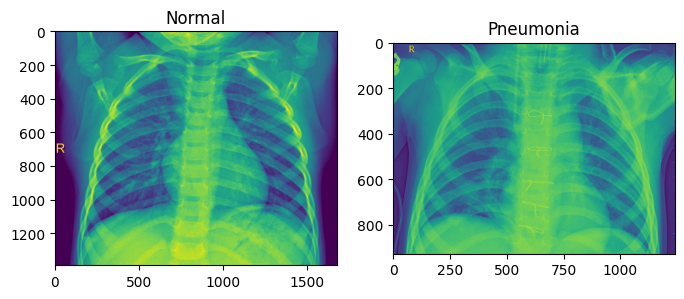

using device: cpu


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch: 1/5 running
Epoch 1 Loss: 0.1878
Epoch: 2/5 running
Epoch 2 Loss: 0.0567
Epoch: 3/5 running
Epoch 3 Loss: 0.0335
Epoch: 4/5 running
Epoch 4 Loss: 0.0272
Epoch: 5/5 running
Epoch 5 Loss: 0.0194
Test Accuracy: 0.7339743589743589


FileNotFoundError: [Errno 2] No such file or directory: ''

In [2]:
# Step-1:- Import necessary libraries
import numpy as np
import os
import torch

# Step-2:- load and explore the data 
train_dir = "/kaggle/input/chest-xray-pneumonia/chest_xray/train"
val_dir   = "/kaggle/input/chest-xray-pneumonia/chest_xray/val"
test_dir  = "/kaggle/input/chest-xray-pneumonia/chest_xray/test"

categories = ["NORMAL", "PNEUMONIA"]

for category in categories:
    print(category, ":", len(os.listdir(os.path.join(train_dir, category))))

for category in categories:
    print(category, ":", len(os.listdir(os.path.join(val_dir, category))))

for category in categories:
    print(category, ":", len(os.listdir(os.path.join(test_dir, category))))

# visualize sample images
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

path1 = os.path.join(train_dir, categories[0], os.listdir(os.path.join(train_dir, categories[0]))[20])
path2 = os.path.join(train_dir, categories[1], os.listdir(os.path.join(train_dir, categories[1]))[20])

img1 = mpimg.imread(path1)
img2 = mpimg.imread(path2)

fig, ax = plt.subplots(1, 2, figsize=(8, 12))
ax[0].set_title("Normal")
ax[0].imshow(img1)

ax[1].set_title("Pneumonia")
ax[1].imshow(img2)

plt.show()

# Step-3: Preprocessing the data 
from torchvision import transforms, datasets

train_transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# read and label the data 
train_data = datasets.ImageFolder(train_dir, transform=train_transform)
val_data   = datasets.ImageFolder(val_dir, transform=val_transform)
test_data  = datasets.ImageFolder(test_dir, transform=test_transform)

# load the data 
from torch.utils.data import DataLoader
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_data, batch_size=32, shuffle=False)

# Step-4:- Device selection
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("using device:", device)

# Step-5:- Defining the model architecture
from torchvision import models
import torch.nn as nn

model = models.inception_v3(pretrained=True, aux_logits=True)

for param in model.parameters():
    param.requires_grad = True

model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 1),
    nn.Sigmoid()
)

model.AuxLogits.fc = nn.Sequential(
    nn.Linear(model.AuxLogits.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 1),
    nn.Sigmoid()
)

model = model.to(device)

# Step-6:- compiling the model
import torch.optim as optim
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# Step-7:- Training the model
epochs = 5

for epoch in range(epochs):
    print(f"Epoch: {epoch+1}/{epochs} running")
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)

        optimizer.zero_grad()
        outputs, aux_outputs = model(images)

        loss = criterion(outputs, labels)
        aux_loss = criterion(aux_outputs, labels)
        loss = loss + 0.4 * aux_loss

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1} Loss: {running_loss/len(train_loader):.4f}")

# Step-8:- Evaluating the model
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        predicted = (outputs > 0.5).int()

        correct += (predicted.squeeze() == labels).sum().item()
        total += labels.size(0)

accuracy = correct / total
print("Test Accuracy:", accuracy)

# Step-9:- Prediction on new image
from PIL import Image

img = Image.open("/kaggle/input/chest-xray-pneumonia/chest_xray/test/PNEUMONIA/person104_bacteria_491.jpeg").convert("RGB")
img = val_transform(img)
img = img.unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    output = model(img)

if output.item() > 0.5:
    print("Diagnosis: Pneumonia")
else:
    print("Diagnosis: Normal")


Pneumonia detection using Inception V3(Tensorflow library)

NORMAL : 1341
PNEUMONIA : 3875
NORMAL : 8
PNEUMONIA : 8
NORMAL : 234
PNEUMONIA : 390


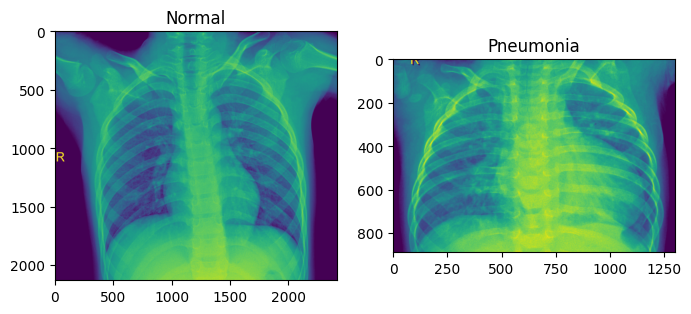

2026-01-27 10:01:01.718749: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769508061.912440    3260 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769508061.969609    3260 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769508062.472123    3260 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769508062.472158    3260 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769508062.472161    3260 computation_placer.cc:177] computation placer alr

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


2026-01-27 10:01:17.017128: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "sequential"

...

 Total params: 22,327,585 (85.17 MB)

 Trainable params: 524,801 (2.00 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 442s 3s/step - accuracy: 0.8210 - loss: 0.4358 - val_accuracy: 0.6875 - val_loss: 0.5381
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 433s 3s/step - accuracy: 0.9245 - loss: 0.1860 - val_accuracy: 0.7500 - val_loss: 0.5197
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 434s 3s/step - accuracy: 0.9295 - loss: 0.1798 - val_accuracy: 0.6875 - val_loss: 0.6581
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 438s 3s/step - accuracy: 0.9350 - loss: 0.1595 - val_accuracy: 0.6875 - val_loss: 0.7621
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 445s 3s/step - accuracy: 0.9412 - loss: 0.1547 - val_accuracy: 0.7500 - val_loss: 0.4322
20/20 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy: 0.8682 - loss: 0.3578
Test accuracy:- 0.8717948794364929
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Diagnosis: Pneumonia


In [4]:
# Step-1:- import necessary library
import numpy as np
import os 

# Step-2:- Load and Explore the data
train_dir = "/kaggle/input/chest-xray-pneumonia/chest_xray/train"
val_dir   = "/kaggle/input/chest-xray-pneumonia/chest_xray/val"
test_dir  = "/kaggle/input/chest-xray-pneumonia/chest_xray/test"

categories = ["NORMAL", "PNEUMONIA"]

for category in categories:
    print(category, ":", len(os.listdir(os.path.join(train_dir, category))))

for category in categories:
    print(category, ":", len(os.listdir(os.path.join(val_dir, category))))

for category in categories:
    print(category, ":", len(os.listdir(os.path.join(test_dir, category))))

# Visualizing sample images
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

path1 = os.path.join(train_dir, categories[0], os.listdir(os.path.join(train_dir, categories[0]))[50])
path2 = os.path.join(train_dir, categories[1], os.listdir(os.path.join(train_dir, categories[1]))[50])

img1 = mpimg.imread(path1)
img2 = mpimg.imread(path2)

fig, ax = plt.subplots(1, 2, figsize=(8, 12))
ax[0].set_title("Normal")
ax[0].imshow(img1)

ax[1].set_title("Pneumonia")
ax[1].imshow(img2)

plt.show()

# Step-3:- Preprocess the data
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_gen = ImageDataGenerator(
    rescale=1./255,
    zoom_range=0.2,
    shear_range=0.1,
    horizontal_flip=True
)

val_gen = ImageDataGenerator(rescale=1./255)
test_gen = ImageDataGenerator(rescale=1./255)

# Read, load and label the data
train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=(299, 299),
    batch_size=32,
    class_mode="binary"
)

val_data = val_gen.flow_from_directory(
    val_dir,
    target_size=(299, 299),
    batch_size=32,
    class_mode="binary"
)

test_data = test_gen.flow_from_directory(
    test_dir,
    target_size=(299, 299),
    batch_size=32,
    class_mode="binary"
)

# Step-4:- Defining the model architecture
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras import models, layers

# Base model
inception_v3_base = InceptionV3(
    weights="imagenet",
    include_top=False,
    input_shape=(299, 299, 3)
)

# Freeze pretrained layers
for layer in inception_v3_base.layers:
    layer.trainable = False

# Custom model
model = models.Sequential([
    inception_v3_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])

# Step-5:- Compile the model
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# Step-6:- Training the model
history = model.fit(
    train_data,
    epochs=5,
    validation_data=val_data
)

# Step-7:- Evaluating the model
test_loss, test_accuracy = model.evaluate(test_data)
print("Test accuracy:-", test_accuracy)

# Step-8:- Prediction on new image
from tensorflow.keras.preprocessing import image

path = "/kaggle/input/chest-xray-pneumonia/chest_xray/test/PNEUMONIA/person100_bacteria_479.jpeg"   # provide image path here
img = image.load_img(path, target_size=(299, 299))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

print("Diagnosis:", "Pneumonia" if prediction[0][0] > 0.5 else "Normal")


Pneumonia Detection using Xception(Tensorflow library)

Train NORMAL : 1341
Train PNEUMONIA : 3875
Validation NORMAL : 8
Validation PNEUMONIA : 8
Test NORMAL : 234
Test PNEUMONIA : 390


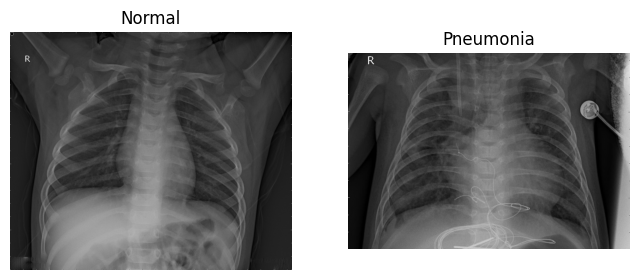

2026-01-29 02:15:52.298793: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769652952.534906      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769652952.604431      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769652953.184879      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769652953.184939      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769652953.184942      55 computation_placer.cc:177] computation placer alr

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


2026-01-29 02:16:15.006062: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

...

 Total params: 21,386,281 (81.58 MB)

 Trainable params: 524,801 (2.00 MB)

 Non-trainable params: 20,861,480 (79.58 MB)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 1206s 7s/step - accuracy: 0.8093 - loss: 0.4061 - val_accuracy: 1.0000 - val_loss: 0.2486
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 1171s 7s/step - accuracy: 0.9135 - loss: 0.2179 - val_accuracy: 1.0000 - val_loss: 0.2166
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 1186s 7s/step - accuracy: 0.9323 - loss: 0.1766 - val_accuracy: 1.0000 - val_loss: 0.1612
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 1187s 7s/step - accuracy: 0.9381 - loss: 0.1583 - val_accuracy: 1.0000 - val_loss: 0.1596
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 1181s 7s/step - accuracy: 0.9431 - loss: 0.1513 - val_accuracy: 1.0000 - val_loss: 0.1417
20/20 ━━━━━━━━━━━━━━━━━━━━ 138s 7s/step - accuracy: 0.8702 - loss: 0.2799
Test Accuracy: 0.8733974099159241
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Diagnosis: Pneumonia


In [1]:
### Step-1:- Import Necessary libraries
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Step-2:- Load and explore the data
train_dir = "/kaggle/input/chest-xray-pneumonia/chest_xray/train"
val_dir   = "/kaggle/input/chest-xray-pneumonia/chest_xray/val"
test_dir  = "/kaggle/input/chest-xray-pneumonia/chest_xray/test"

categories = ["NORMAL", "PNEUMONIA"]

# Count images in each category
for category in categories:
    print("Train", category, ":", len(os.listdir(os.path.join(train_dir, category))))

for category in categories:
    print("Validation", category, ":", len(os.listdir(os.path.join(val_dir, category))))

for category in categories:
    print("Test", category, ":", len(os.listdir(os.path.join(test_dir, category))))

# Step-2.1:- Visualizing sample images
path1 = os.path.join(train_dir, categories[0])
path1 = os.path.join(path1, os.listdir(path1)[0])

path2 = os.path.join(train_dir, categories[1])
path2 = os.path.join(path2, os.listdir(path2)[0])

img1 = mpimg.imread(path1)
img2 = mpimg.imread(path2)

fig, ax = plt.subplots(1, 2, figsize=(8, 6))
ax[0].set_title("Normal")
ax[0].imshow(img1, cmap="gray")
ax[0].axis("off")

ax[1].set_title("Pneumonia")
ax[1].imshow(img2, cmap="gray")
ax[1].axis("off")

plt.show()

# Step-3:- Preprocess the data
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_gen = ImageDataGenerator(
    rescale=1./255,
    zoom_range=0.2,
    shear_range=0.1,
    horizontal_flip=True
)

val_gen = ImageDataGenerator(rescale=1./255)
test_gen = ImageDataGenerator(rescale=1./255)

# Read, load, and label the data
train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=(299, 299),
    batch_size=32,
    class_mode="binary"
)

val_data = val_gen.flow_from_directory(
    val_dir,
    target_size=(299, 299),
    batch_size=32,
    class_mode="binary",
)

test_data = test_gen.flow_from_directory(
    test_dir,
    target_size=(299, 299),
    batch_size=32,
    class_mode="binary",
)

# Step-4:- Defining the model architecture
from tensorflow.keras.applications import Xception

xception_base = Xception(
    weights="imagenet",
    include_top=False,
    input_shape=(299, 299, 3)
)

# Freeze pretrained layers
for layer in xception_base.layers:
    layer.trainable = False

# Build the model
from tensorflow.keras import models, layers

model = models.Sequential([
    xception_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])

# Step-5:- Compile the model
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# Step-6:- Training the model
history = model.fit(
    train_data,
    epochs=5,
    validation_data=val_data
)

# Step-7:- Evaluating the model
test_loss, test_accuracy = model.evaluate(test_data)
print("Test Accuracy:", test_accuracy)

# Step-8:- Prediction on new image
from tensorflow.keras.preprocessing import image

path = "/kaggle/input/chest-xray-pneumonia/chest_xray/val/PNEUMONIA/person1954_bacteria_4886.jpeg"

img = image.load_img(path, target_size=(299, 299))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

diagnosis = "Pneumonia" if prediction[0][0] > 0.5 else "Normal"
print("Diagnosis:", diagnosis)
